# House Price Prediction - Exploratory Data Analysis

This notebook contains comprehensive EDA for the house price prediction dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load and Inspect Data

In [2]:
# Load the dataset
df = pd.read_excel('../Case Study 1 Data.xlsx', engine='openpyxl')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (247172, 10)
Total Records: 247,172
Total Features: 10


In [3]:
# Display first few rows
df.head(10)

,Property ID,Location,Size,Bedrooms,Bathrooms,Year Built,Condition,Type,Date Sold,Price
0,SI_000001,CityA,3974.0,2.0,2.0,2007.0,Good,Single Family,2020-11-02,324000.0
1,SI_000002,CityA,1660.0,2.0,3.0,1934.0,Good,Single Family,2022-10-23,795000.0
2,SI_000003,CityC,2094.0,2.0,2.0,1950.0,Good,Single Family,2020-11-30,385000.0
3,SI_000004,CityB,1930.0,2.0,3.0,1905.0,Good,Single Family,2021-12-09,651000.0
4,SI_000005,CityB,1895.0,5.0,2.0,1936.0,New,Single Family,2024-10-30,1878000.0
5,SI_000006,CityB,3892.0,2.0,3.0,1904.0,Poor,Single Family,2020-05-16,213000.0
6,SI_000007,CityA,2438.0,3.0,2.0,1955.0,Fair,Single Family,2022-01-12,417000.0
7,SI_000008,CityA,2969.0,4.0,1.0,1958.0,Good,Single Family,2024-08-09,621000.0
8,SI_000009,CityD,1266.0,2.0,2.0,1938.0,Good,Single Family,2021-07-14,470000.0
9,SI_000010,CityA,2038.0,5.0,3.0,2000.0,Fair,Single Family,2020-02-09,409000.0


In [4]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247172 entries, 0 to 247171
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Property ID  247172 non-null  object        
 1   Location     247172 non-null  object        
 2   Size         244701 non-null  float64       
 3   Bedrooms     238769 non-null  float64       
 4   Bathrooms    240499 non-null  float64       
 5   Year Built   234567 non-null  float64       
 6   Condition    236544 non-null  object        
 7   Type         247172 non-null  object        
 8   Date Sold    247172 non-null  datetime64[ns]
 9   Price        241735 non-null  float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 18.9+ MB


In [5]:
# Column names
print("Columns in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Columns in dataset:
1. Property ID
2. Location
3. Size
4. Bedrooms
5. Bathrooms
6. Year Built
7. Condition
8. Type
9. Date Sold
10. Price


In [6]:
# Statistical summary for numerical columns
df.describe()

,Size,Bedrooms,Bathrooms,Year Built,Date Sold,Price
count,244701.000000,238769.000000,240499.000000,234567.000000,247172,2.417350e+05
mean,2402.547664,3.000457,2.002823,1961.429191,2022-07-02 05:00:11.127473664,4.660883e+05
min,800.000000,1.000000,1.000000,1900.000000,2020-01-01 00:00:00,2.600000e+04
25%,1603.000000,2.000000,1.000000,1931.000000,2021-04-02 00:00:00,3.000000e+05
50%,2404.000000,3.000000,2.000000,1961.000000,2022-07-03 00:00:00,4.170000e+05
75%,3203.000000,4.000000,3.000000,1992.000000,2023-10-02 00:00:00,5.770000e+05
max,3999.000000,5.000000,3.000000,2023.000000,2024-12-31 00:00:00,2.223000e+06
std,923.418566,1.415088,0.816616,35.752638,NaN,2.315026e+05


In [7]:
# Statistical summary for categorical columns
df.describe(include='object')

,Property ID,Location,Condition,Type
count,247172,247172,236544,247172
unique,247172,4,4,3
top,SI_000001,CityC,Good,Townhouse
freq,1,62082,94629,100000


## 2. Missing Values Analysis

In [8]:
# Check for missing values
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

if len(missing_data) > 0:
    print("Missing Values Summary:")
    display(missing_data)
else:
    print("No missing values found in the dataset!")

Missing Values Summary:


,Missing Count,Missing Percentage
Year Built,12605,5.1
Condition,10628,4.3
Bedrooms,8403,3.4
Bathrooms,6673,2.7
Price,5437,2.2
Size,2471,1.0


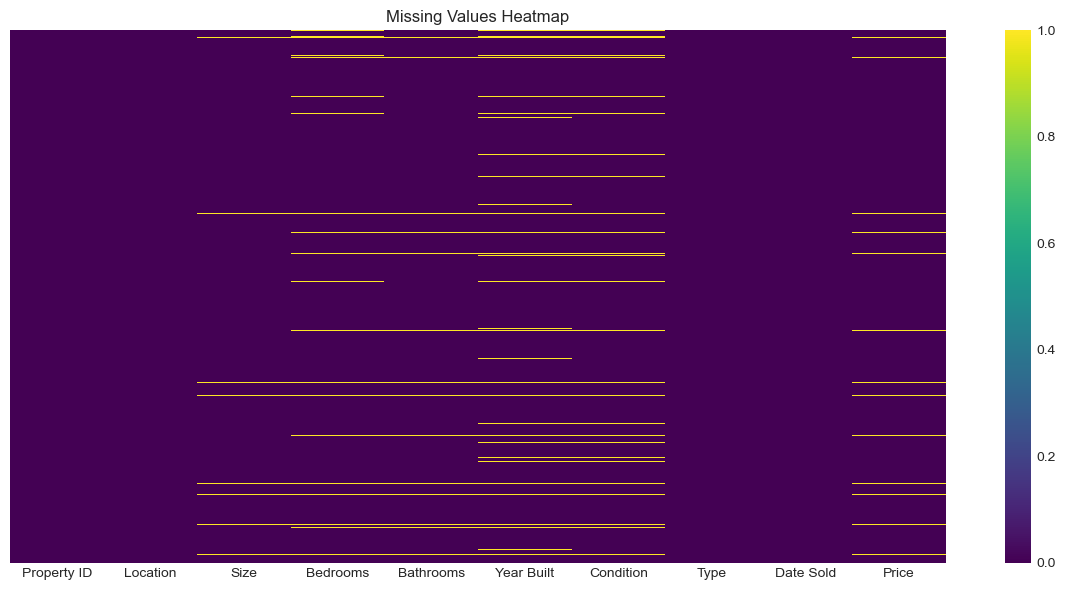

In [9]:
# Visualize missing values if any exist
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.tight_layout()
    plt.show()

## 3. Duplicate Analysis

In [10]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# Check for duplicate Property IDs (if column exists)
property_id_col = [col for col in df.columns if 'property' in col.lower() and 'id' in col.lower()]
if property_id_col:
    dup_ids = df[property_id_col[0]].duplicated().sum()
    print(f"Duplicate Property IDs: {dup_ids}")

Total duplicate rows: 0
Duplicate Property IDs: 0


## 4. Target Variable Analysis (Price)

In [11]:
# Find the price column
price_col = [col for col in df.columns if 'price' in col.lower()]
if price_col:
    price_col = price_col[0]
    print(f"Price column: {price_col}")
    print(f"\nPrice Statistics:")
    print(df[price_col].describe())
else:
    price_col = 'Price'  # Default assumption

Price column: Price

Price Statistics:
count    2.417350e+05
mean     4.660883e+05
std      2.315026e+05
min      2.600000e+04
25%      3.000000e+05
50%      4.170000e+05
75%      5.770000e+05
max      2.223000e+06
Name: Price, dtype: float64


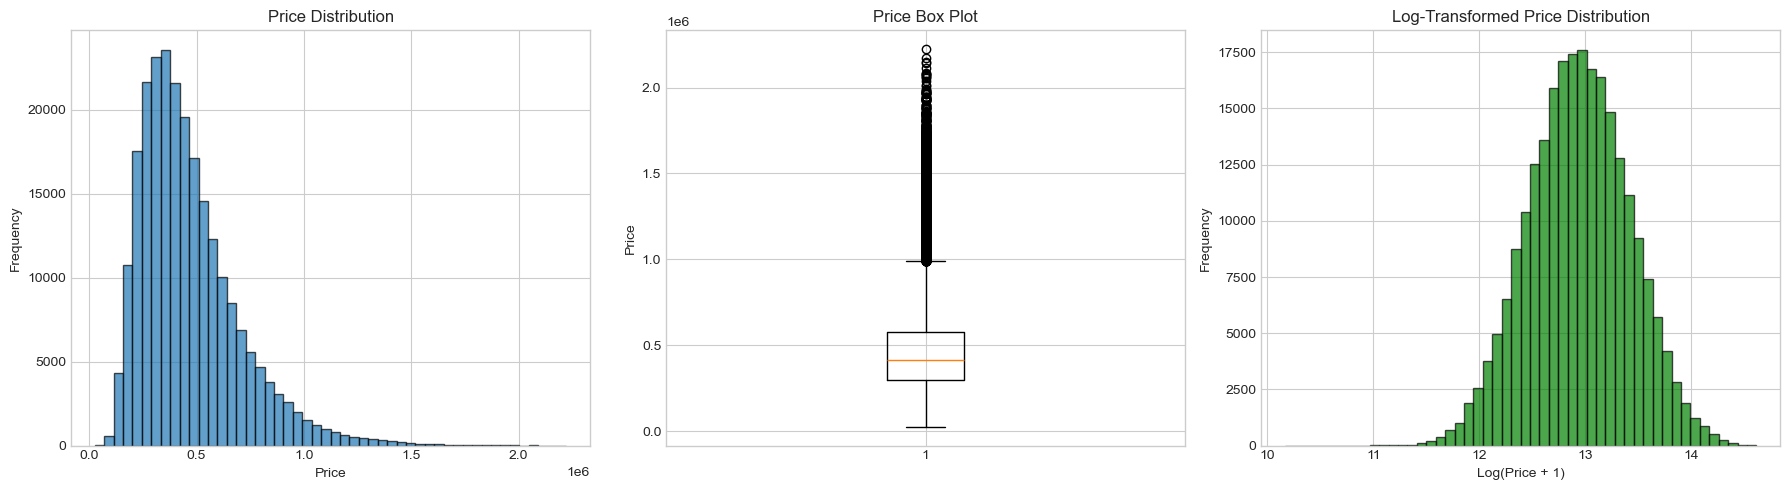

In [12]:
# Price distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df[price_col], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')

# Box plot
axes[1].boxplot(df[price_col].dropna())
axes[1].set_ylabel('Price')
axes[1].set_title('Price Box Plot')

# Log-transformed distribution
axes[2].hist(np.log1p(df[price_col]), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Log(Price + 1)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed Price Distribution')

plt.tight_layout()
plt.show()

In [13]:
# Check skewness of price
print(f"Skewness of Price: {df[price_col].skew():.4f}")
print(f"Kurtosis of Price: {df[price_col].kurtosis():.4f}")
print(f"\nSkewness of Log(Price): {np.log1p(df[price_col]).skew():.4f}")

Skewness of Price: 1.3856
Kurtosis of Price: 2.8981

Skewness of Log(Price): -0.0153


## 5. Numerical Features Analysis

In [14]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['Size', 'Bedrooms', 'Bathrooms', 'Year Built', 'Price']


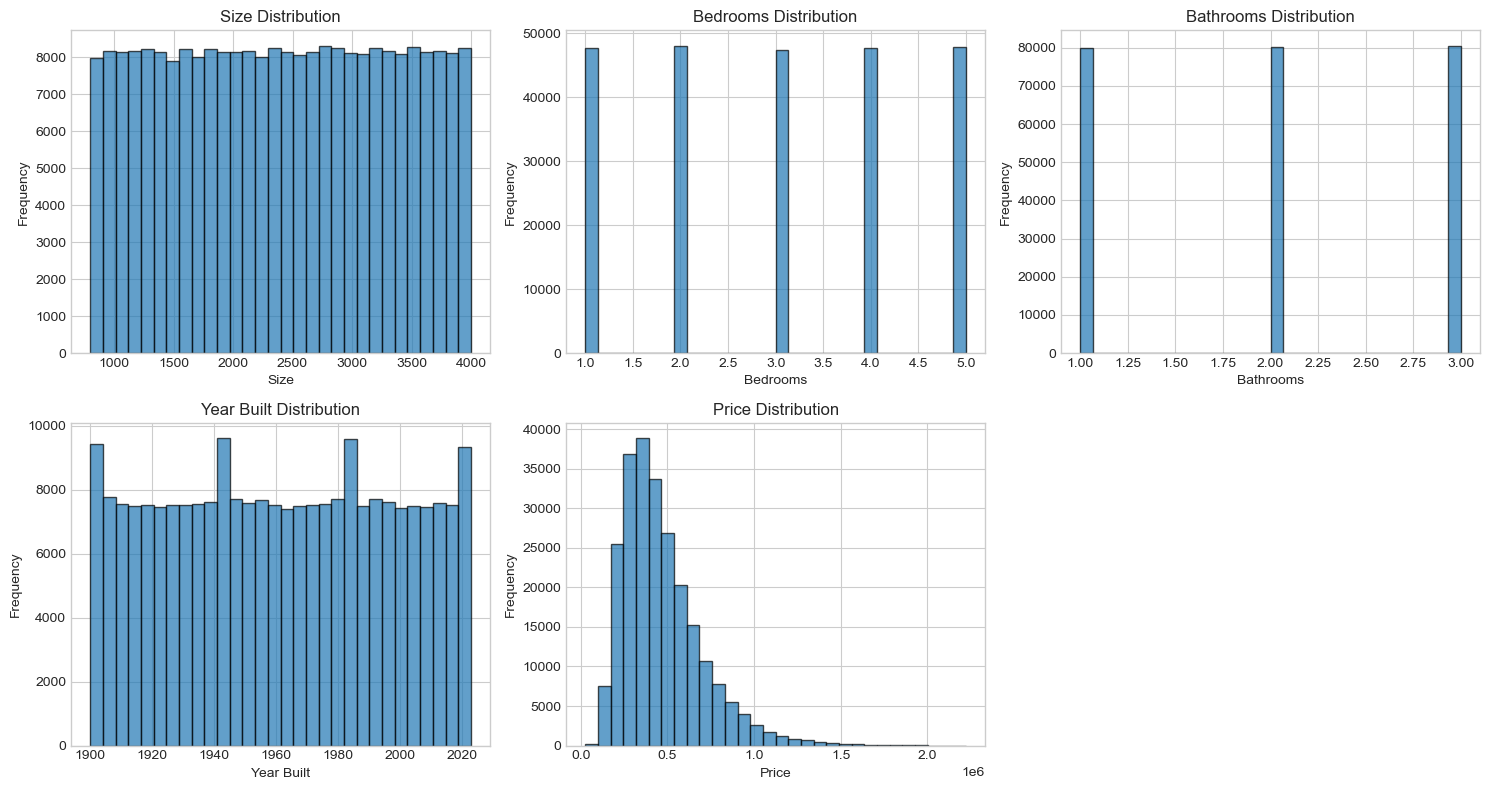

In [15]:
# Distribution plots for numerical features
num_cols_to_plot = [col for col in numerical_cols if col.lower() not in ['property id', 'propertyid', 'id']]

n_cols = 3
n_rows = (len(num_cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{col} Distribution')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

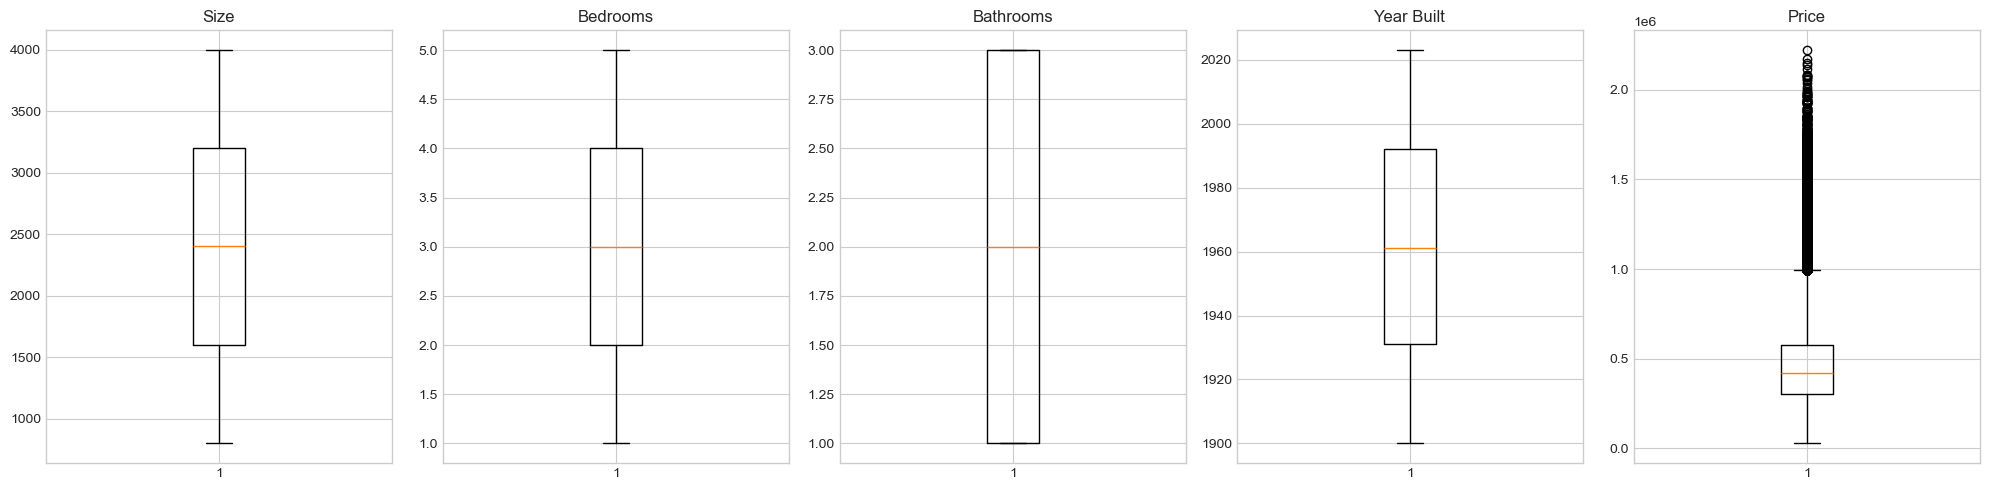

In [16]:
# Box plots for numerical features
fig, axes = plt.subplots(1, len(num_cols_to_plot), figsize=(4*len(num_cols_to_plot), 5))
if len(num_cols_to_plot) == 1:
    axes = [axes]

for i, col in enumerate(num_cols_to_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## 6. Categorical Features Analysis

In [17]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['Property ID', 'Location', 'Condition', 'Type']


In [18]:
# Unique values in each categorical column
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    if df[col].nunique() <= 20:
        print(f"  Values: {df[col].unique().tolist()}")


Property ID:
  Unique values: 247172

Location:
  Unique values: 4
  Values: ['CityA', 'CityC', 'CityB', 'CityD']

Condition:
  Unique values: 4
  Values: ['Good', 'New', 'Poor', 'Fair', nan]

Type:
  Unique values: 3
  Values: ['Single Family', 'Condominium', 'Townhouse']


In [19]:
# Value counts for categorical columns
for col in categorical_cols:
    if df[col].nunique() <= 20:
        print(f"\n{col} Value Counts:")
        print(df[col].value_counts())


Location Value Counts:
Location
CityC    62082
CityA    61916
CityD    61724
CityB    61450
Name: count, dtype: int64

Condition Value Counts:
Condition
Good    94629
Fair    71194
Poor    47244
New     23477
Name: count, dtype: int64

Type Value Counts:
Type
Townhouse        100000
Single Family     88261
Condominium       58911
Name: count, dtype: int64


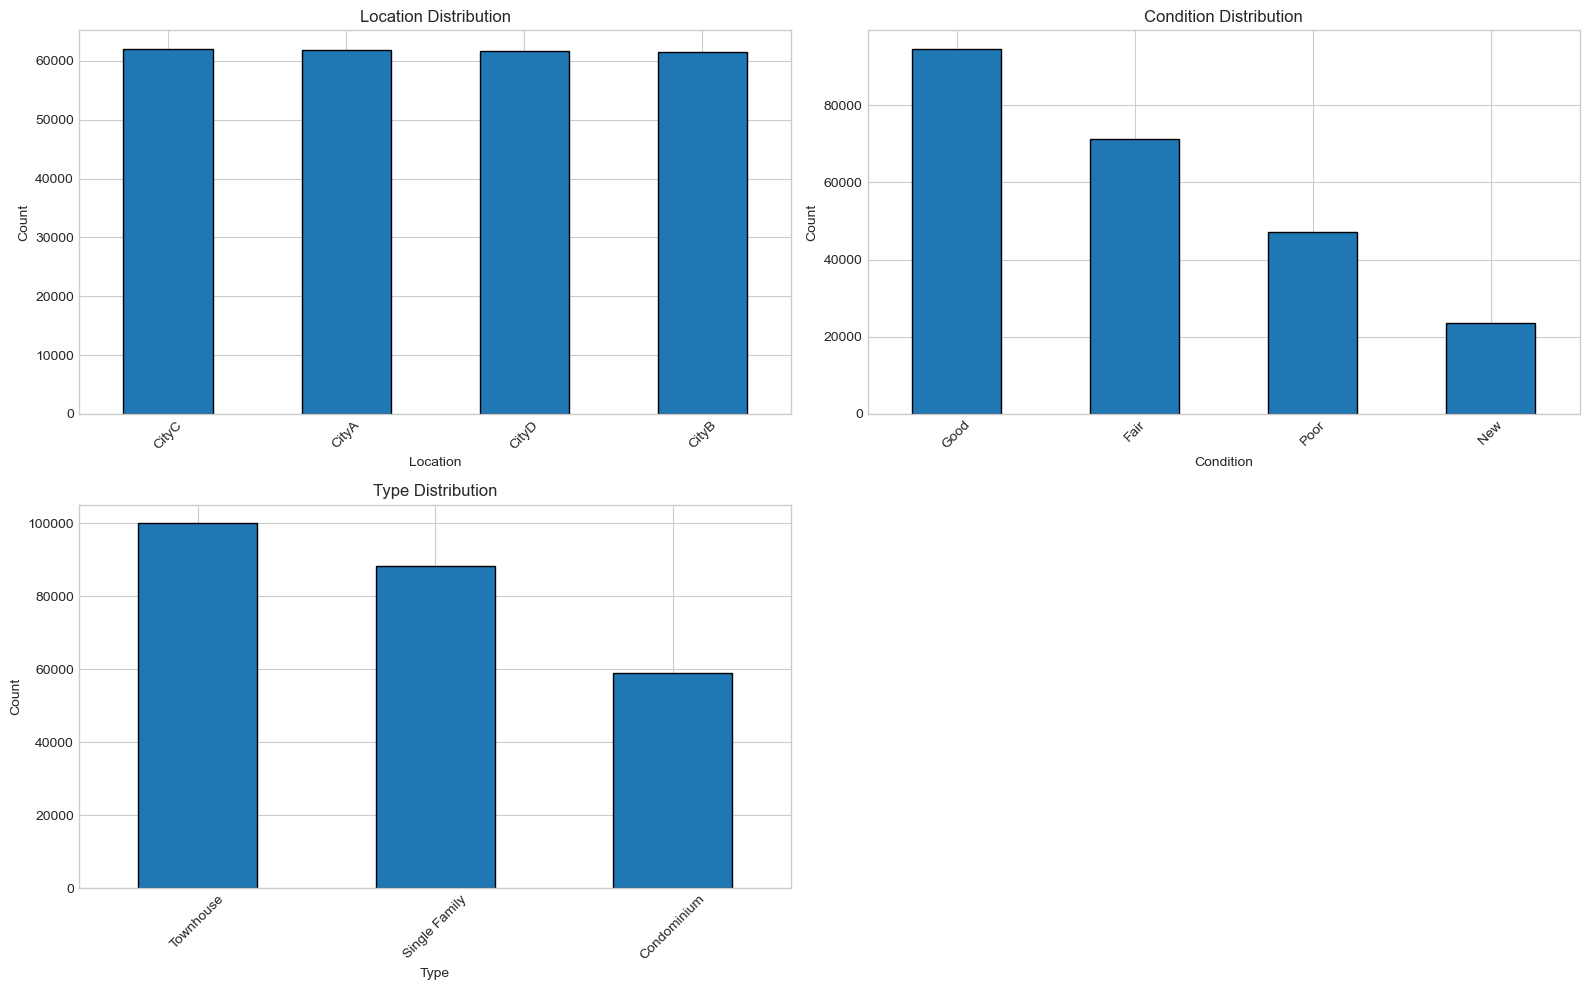

In [20]:
# Bar plots for categorical features with reasonable cardinality
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 15]

if cat_cols_to_plot:
    n_cols = min(2, len(cat_cols_to_plot))
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 5*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(f'{col} Distribution')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## 7. Correlation Analysis

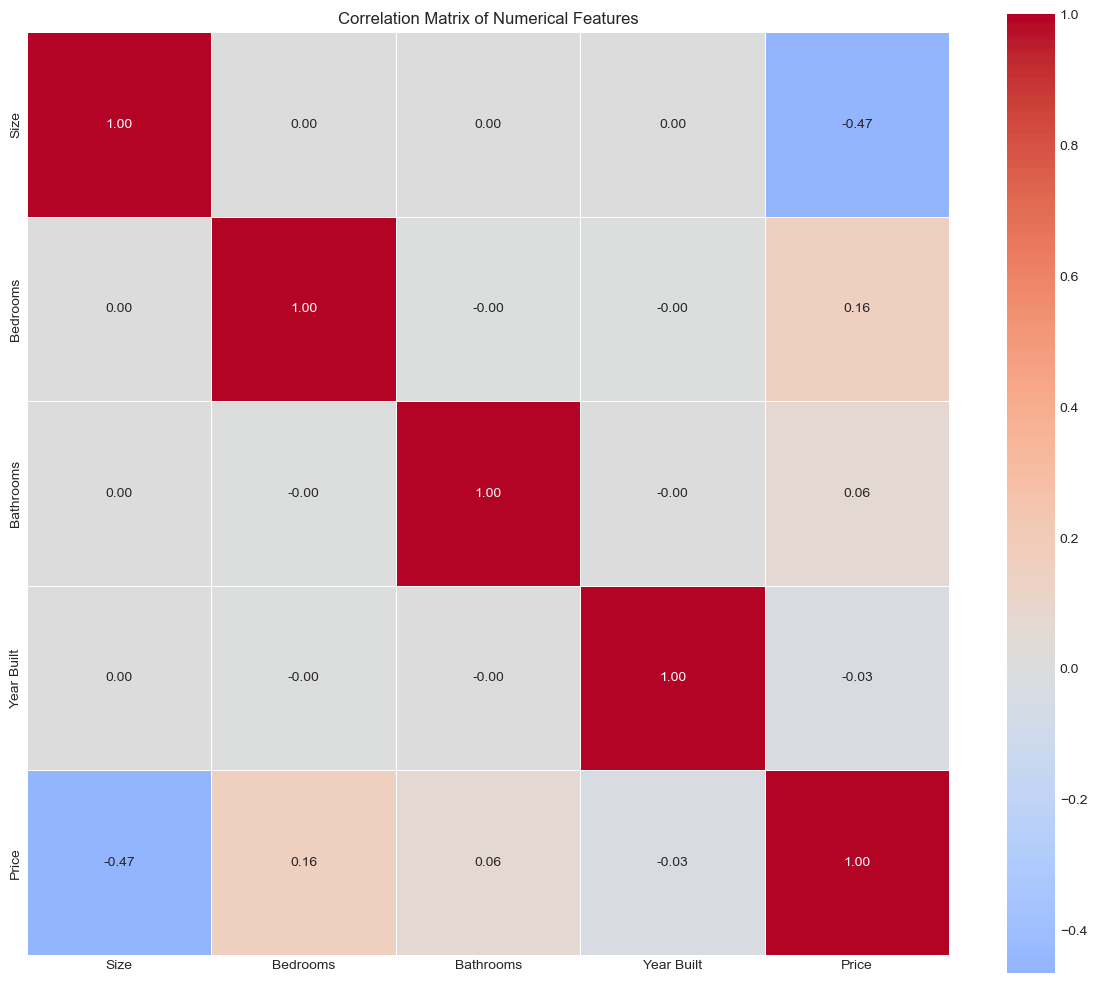

In [21]:
# Correlation matrix for numerical features
corr_cols = [col for col in numerical_cols if col.lower() not in ['property id', 'propertyid', 'id']]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [22]:
# Correlation with target variable (Price)
if price_col in df.columns:
    correlations = df[corr_cols].corr()[price_col].sort_values(ascending=False)
    print("Correlation with Price:")
    print(correlations)

Correlation with Price:
Price         1.000000
Bedrooms      0.162446
Bathrooms     0.057608
Year Built   -0.030181
Size         -0.465010
Name: Price, dtype: float64


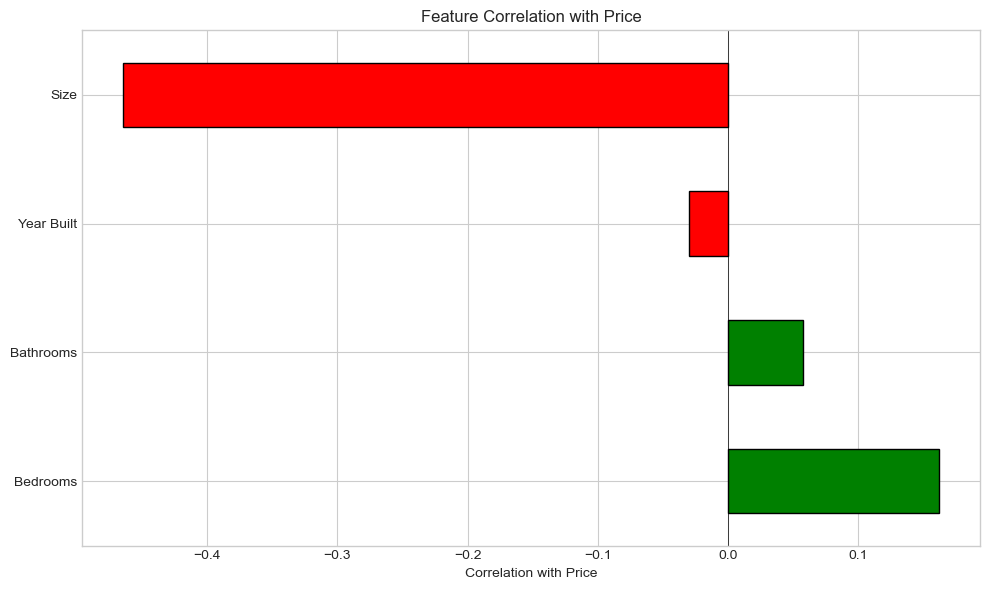

In [23]:
# Correlation bar plot
if price_col in df.columns:
    correlations_no_price = correlations.drop(price_col)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in correlations_no_price.values]
    correlations_no_price.plot(kind='barh', color=colors, edgecolor='black')
    plt.xlabel('Correlation with Price')
    plt.title('Feature Correlation with Price')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## 8. Feature vs Price Analysis

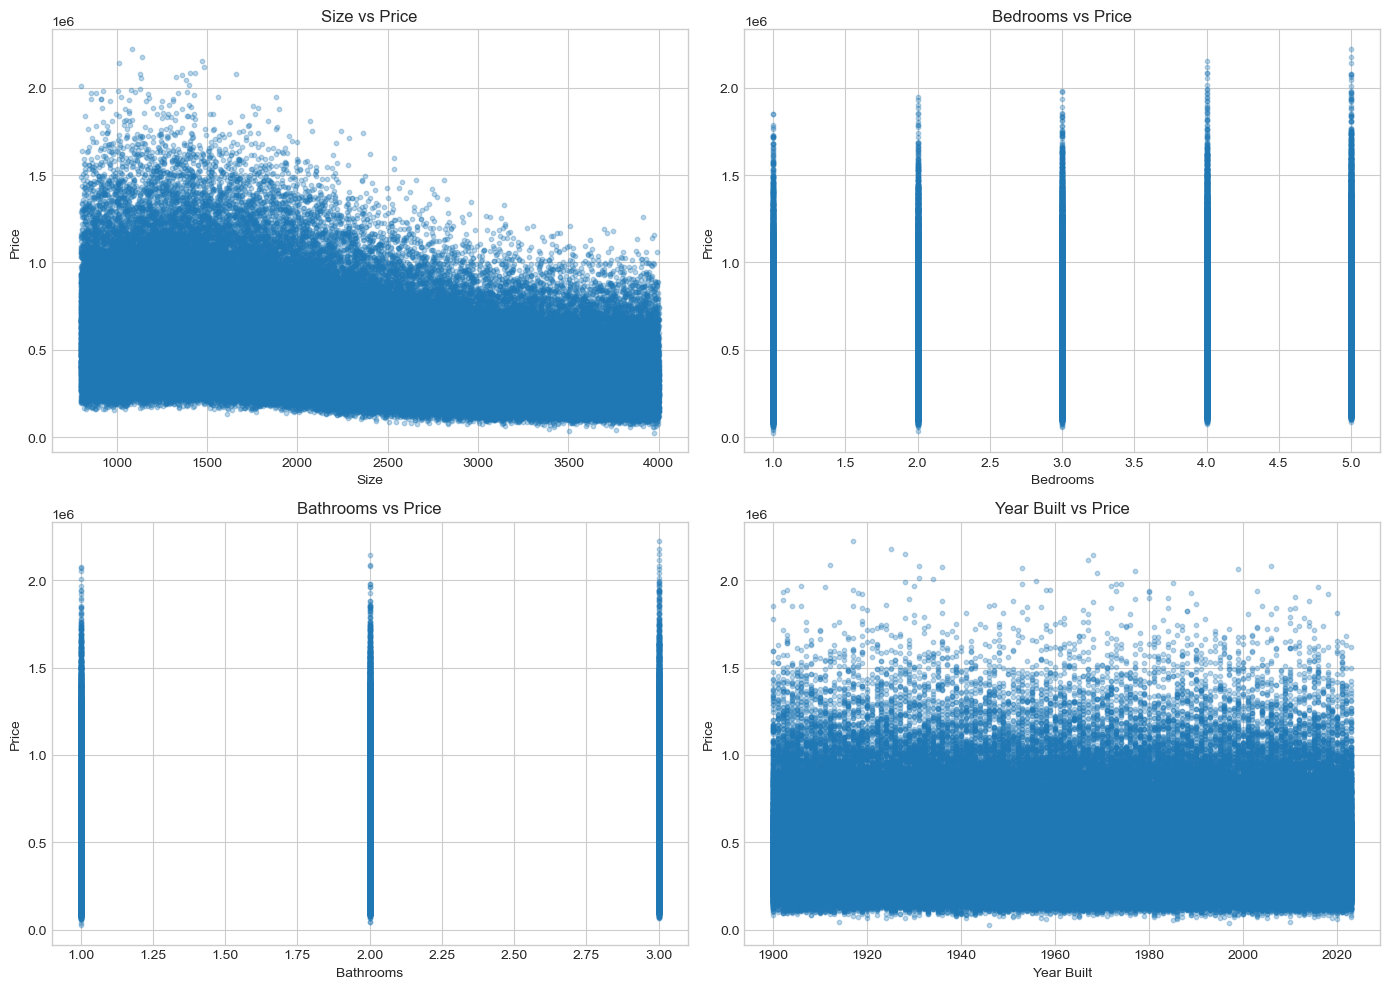

In [24]:
# Scatter plots of numerical features vs Price
num_features = [col for col in numerical_cols if col.lower() not in ['property id', 'propertyid', 'id', 'price']]

if price_col in df.columns and num_features:
    n_cols = 2
    n_rows = (len(num_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, col in enumerate(num_features):
        axes[i].scatter(df[col], df[price_col], alpha=0.3, s=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Price')
        axes[i].set_title(f'{col} vs Price')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

<Figure size 1200x600 with 0 Axes>

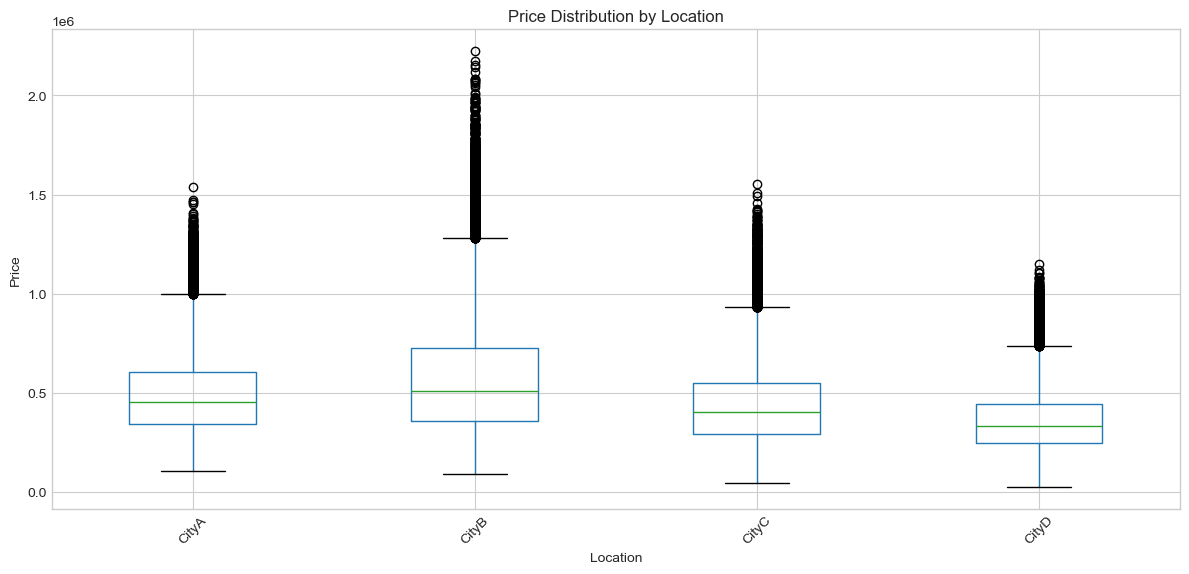

<Figure size 1200x600 with 0 Axes>

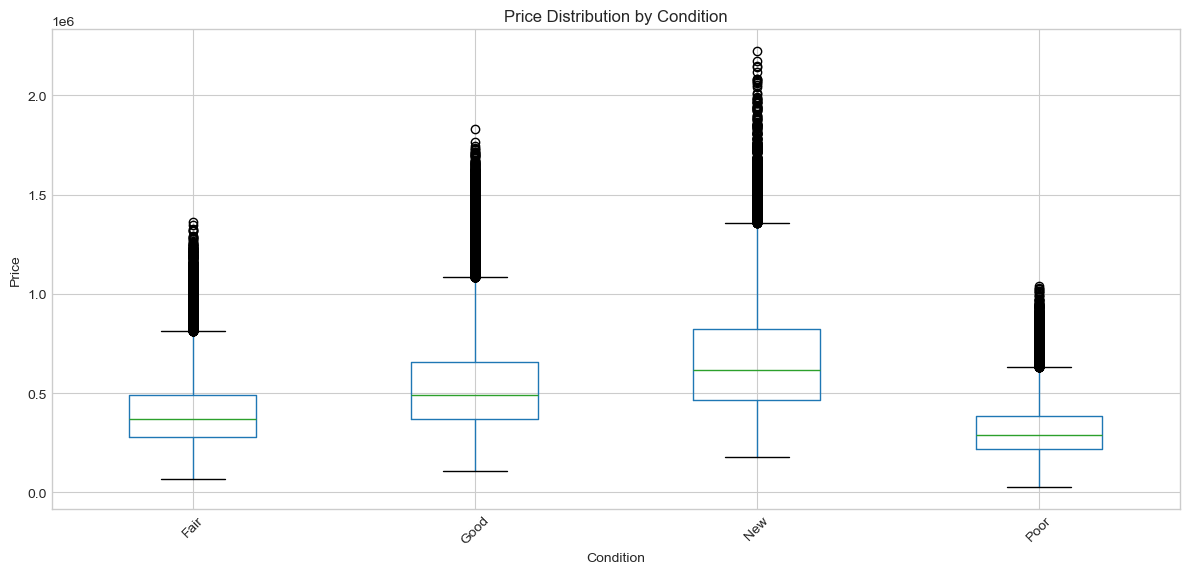

<Figure size 1200x600 with 0 Axes>

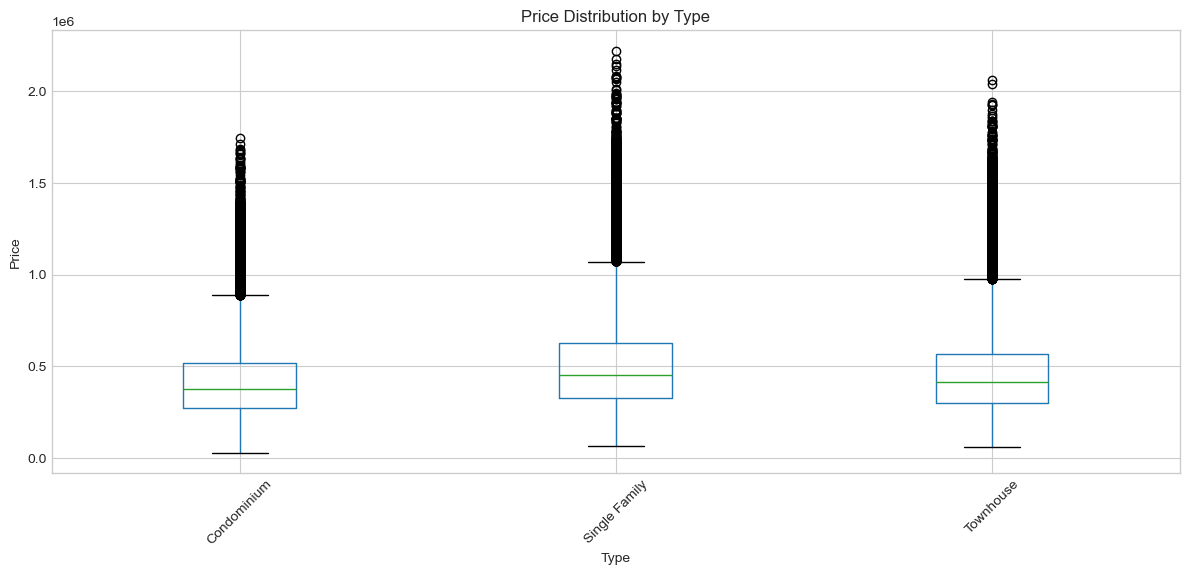

In [25]:
# Box plots of Price by categorical features
cat_features = [col for col in categorical_cols if df[col].nunique() <= 10]

if price_col in df.columns and cat_features:
    for col in cat_features:
        plt.figure(figsize=(12, 6))
        df.boxplot(column=price_col, by=col, figsize=(12, 6))
        plt.title(f'Price Distribution by {col}')
        plt.suptitle('')  # Remove automatic title
        plt.xlabel(col)
        plt.ylabel('Price')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## 9. Date Analysis (if Date Sold exists)

In [26]:
# Find date column
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    date_col = date_cols[0]
    print(f"Date column found: {date_col}")
    
    # Convert to datetime if needed
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
else:
    print("No date column found")

Date column found: Date Sold
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00


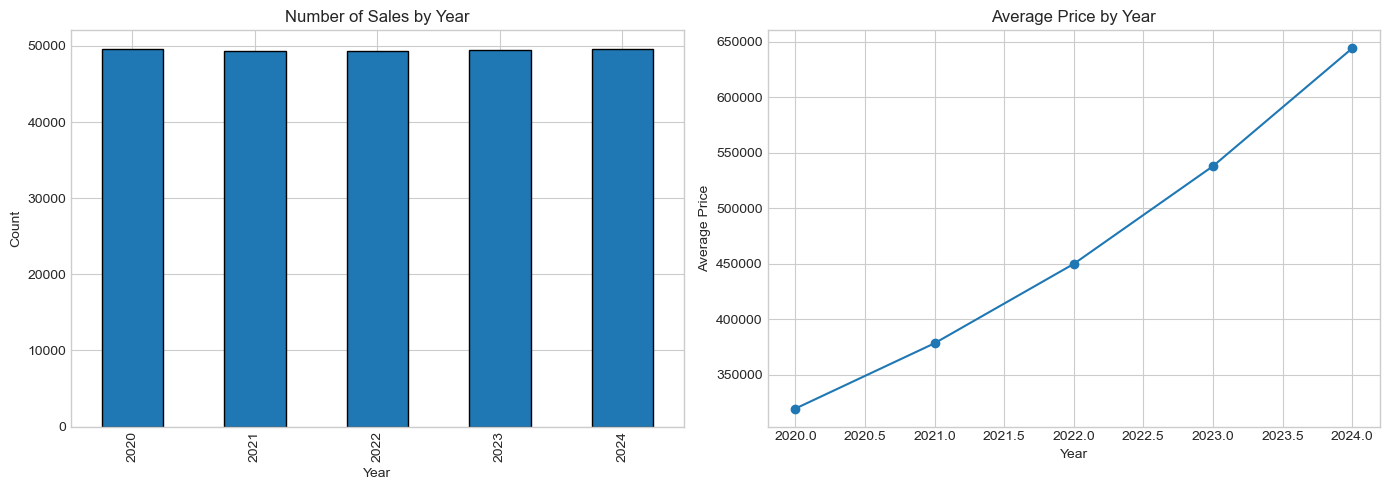

In [27]:
# Extract date features if date column exists
if date_cols:
    df['sale_year'] = df[date_col].dt.year
    df['sale_month'] = df[date_col].dt.month
    df['sale_quarter'] = df[date_col].dt.quarter
    
    # Sales trend over time
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sales by year
    df.groupby('sale_year').size().plot(kind='bar', ax=axes[0], edgecolor='black')
    axes[0].set_title('Number of Sales by Year')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Count')
    
    # Average price by year
    df.groupby('sale_year')[price_col].mean().plot(kind='line', marker='o', ax=axes[1])
    axes[1].set_title('Average Price by Year')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Average Price')
    
    plt.tight_layout()
    plt.show()

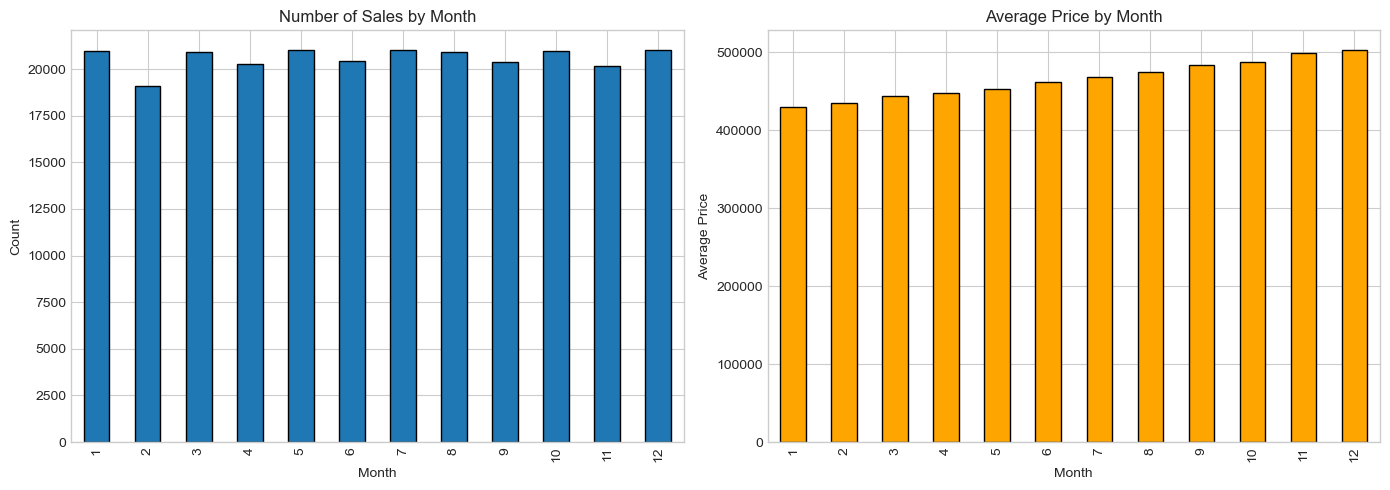

In [28]:
# Monthly seasonality
if date_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df.groupby('sale_month').size().plot(kind='bar', ax=axes[0], edgecolor='black')
    axes[0].set_title('Number of Sales by Month')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Count')
    
    df.groupby('sale_month')[price_col].mean().plot(kind='bar', ax=axes[1], edgecolor='black', color='orange')
    axes[1].set_title('Average Price by Month')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Average Price')
    
    plt.tight_layout()
    plt.show()

## 10. Property Age Analysis

Property Age Statistics:
count    234567.000000
mean         60.571594
std          35.780711
min          -3.000000
25%          30.000000
50%          61.000000
75%          91.000000
max         124.000000
Name: property_age, dtype: float64


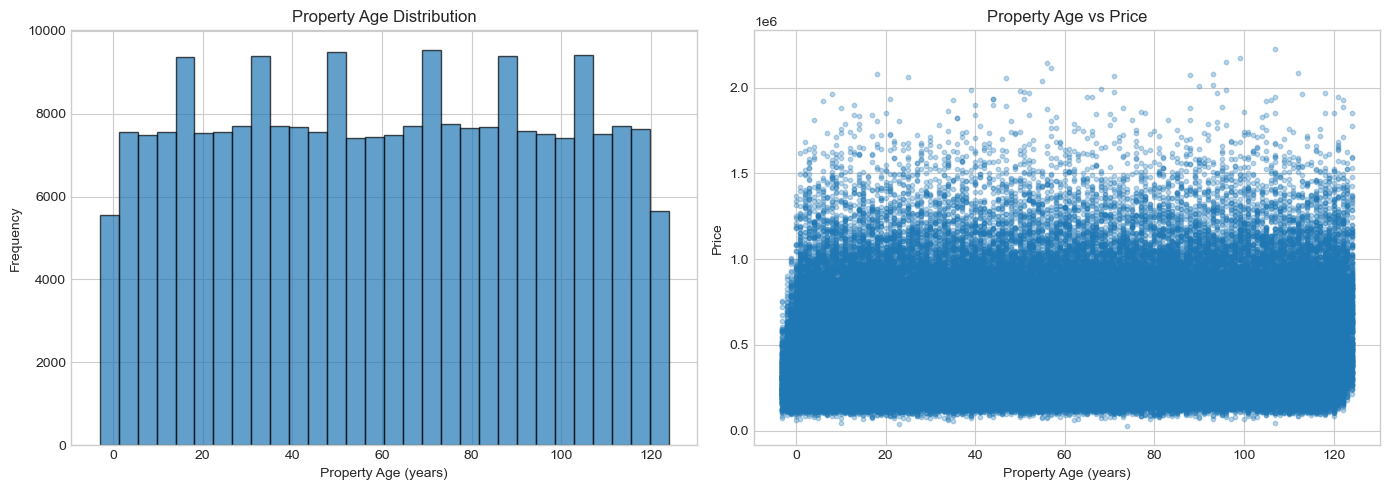

In [29]:
# Find year built column
year_built_col = [col for col in df.columns if 'year' in col.lower() and 'built' in col.lower()]
if year_built_col and date_cols:
    year_built_col = year_built_col[0]
    
    # Calculate property age
    df['property_age'] = df['sale_year'] - df[year_built_col]
    
    print(f"Property Age Statistics:")
    print(df['property_age'].describe())
    
    # Property age distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(df['property_age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Property Age (years)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Property Age Distribution')
    
    # Property age vs Price
    axes[1].scatter(df['property_age'], df[price_col], alpha=0.3, s=10)
    axes[1].set_xlabel('Property Age (years)')
    axes[1].set_ylabel('Price')
    axes[1].set_title('Property Age vs Price')
    
    plt.tight_layout()
    plt.show()

## 11. Outlier Detection

In [30]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detect outliers in key numerical columns
print("Outlier Analysis (IQR Method):")
print("=" * 60)
for col in num_cols_to_plot:
    outlier_count, lb, ub = detect_outliers_iqr(df, col)
    print(f"\n{col}:")
    print(f"  Outliers: {outlier_count} ({outlier_count/len(df)*100:.2f}%)")
    print(f"  Bounds: [{lb:.2f}, {ub:.2f}]")

Outlier Analysis (IQR Method):

Size:
  Outliers: 0 (0.00%)
  Bounds: [-797.00, 5603.00]

Bedrooms:
  Outliers: 0 (0.00%)
  Bounds: [-1.00, 7.00]

Bathrooms:
  Outliers: 0 (0.00%)
  Bounds: [-2.00, 6.00]

Year Built:
  Outliers: 0 (0.00%)
  Bounds: [1839.50, 2083.50]

Price:
  Outliers: 7980 (3.23%)
  Bounds: [-115500.00, 992500.00]


## 12. Location Analysis

In [31]:
# Find location column
location_col = [col for col in df.columns if 'location' in col.lower()]
if location_col:
    location_col = location_col[0]
    print(f"Location column: {location_col}")
    print(f"Number of unique locations: {df[location_col].nunique()}")
    
    # Top 20 locations by count
    print(f"\nTop 20 locations by number of properties:")
    print(df[location_col].value_counts().head(20))

Location column: Location
Number of unique locations: 4

Top 20 locations by number of properties:
Location
CityC    62082
CityA    61916
CityD    61724
CityB    61450
Name: count, dtype: int64


In [32]:
# Average price by location (top 20)
if location_col:
    avg_price_by_location = df.groupby(location_col)[price_col].agg(['mean', 'count', 'median'])
    avg_price_by_location.columns = ['Mean Price', 'Count', 'Median Price']
    
    # Top 20 most expensive locations
    print("Top 20 Most Expensive Locations:")
    display(avg_price_by_location.sort_values('Mean Price', ascending=False).head(20))

Top 20 Most Expensive Locations:


,Mean Price,Count,Median Price
Location,,,
CityB,576302.025936,60071,510000.0
CityA,490389.592820,60612,456000.0
CityC,440601.218809,60715,403000.0
CityD,357595.074332,60337,331000.0


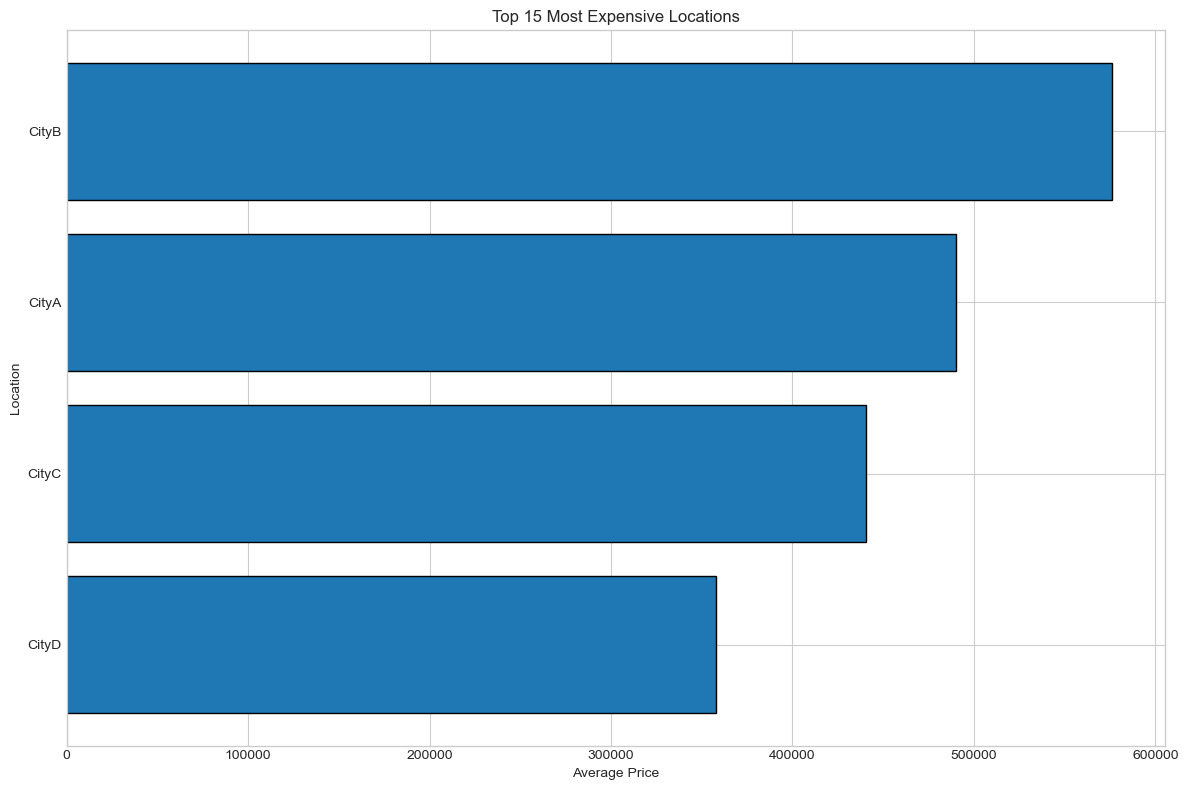

In [33]:
# Plot top 15 locations by average price
if location_col:
    top_locations = avg_price_by_location.sort_values('Mean Price', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_locations)), top_locations['Mean Price'], edgecolor='black')
    plt.yticks(range(len(top_locations)), top_locations.index)
    plt.xlabel('Average Price')
    plt.ylabel('Location')
    plt.title('Top 15 Most Expensive Locations')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. Feature Engineering Preview

In [34]:
# Create potential features for modeling
size_col = [col for col in df.columns if 'size' in col.lower()]
bedroom_col = [col for col in df.columns if 'bedroom' in col.lower()]
bathroom_col = [col for col in df.columns if 'bathroom' in col.lower()]

if size_col and bedroom_col:
    size_col = size_col[0]
    bedroom_col = bedroom_col[0]
    
    # Size per bedroom
    df['size_per_bedroom'] = df[size_col] / (df[bedroom_col] + 1)  # +1 to avoid division by zero
    
    print("Size per Bedroom Statistics:")
    print(df['size_per_bedroom'].describe())

if bedroom_col and bathroom_col:
    bedroom_col = bedroom_col[0] if isinstance(bedroom_col, list) else bedroom_col
    bathroom_col = bathroom_col[0]
    
    # Bed-bath ratio
    df['bed_bath_ratio'] = df[bedroom_col] / (df[bathroom_col] + 1)  # +1 to avoid division by zero
    
    print("\nBed-Bath Ratio Statistics:")
    print(df['bed_bath_ratio'].describe())

Size per Bedroom Statistics:
count    238769.000000
mean        696.441365
std         406.205044
min         133.333333
25%         401.166667
50%         600.666667
75%         888.000000
max        1999.500000
Name: size_per_bedroom, dtype: float64

Bed-Bath Ratio Statistics:
count    238769.000000
mean          1.082856
std           0.617540
min           0.250000
25%           0.500000
50%           1.000000
75%           1.500000
max           2.500000
Name: bed_bath_ratio, dtype: float64


Price per Square Foot Statistics:
count    241735.000000
mean        257.465084
std         220.114277
min           6.542526
25%         103.118545
50%         179.219601
75%         343.423644
max        2508.750000
Name: price_per_sqft, dtype: float64


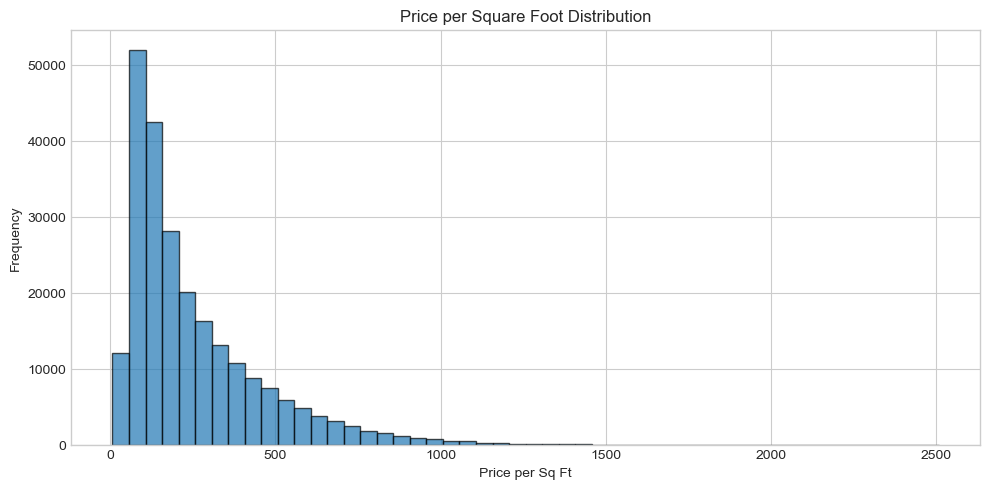

In [35]:
# Price per square foot (for analysis only)
if size_col and price_col:
    if isinstance(size_col, list):
        size_col = size_col[0]
    
    df['price_per_sqft'] = df[price_col] / df[size_col]
    
    print("Price per Square Foot Statistics:")
    print(df['price_per_sqft'].describe())
    
    # Distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df['price_per_sqft'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Price per Sq Ft')
    plt.ylabel('Frequency')
    plt.title('Price per Square Foot Distribution')
    plt.tight_layout()
    plt.show()

## 14. Summary Statistics

In [36]:
# Final summary
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print(f"\nNumerical Features: {len(numerical_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

if price_col in df.columns:
    print(f"\nTarget Variable (Price):")
    print(f"  Min: ${df[price_col].min():,.2f}")
    print(f"  Max: ${df[price_col].max():,.2f}")
    print(f"  Mean: ${df[price_col].mean():,.2f}")
    print(f"  Median: ${df[price_col].median():,.2f}")

print("\n" + "=" * 60)

EDA SUMMARY

Dataset Shape: (247172, 17)
Total Records: 247,172

Numerical Features: 5
Categorical Features: 4

Missing Values: 81065
Duplicate Rows: 0

Target Variable (Price):
  Min: $26,000.00
  Max: $2,223,000.00
  Mean: $466,088.28
  Median: $417,000.00



In [ ]:
# Save cleaned data for modeling
# df.to_csv('../data/cleaned_data.csv', index=False)
# print("Cleaned data saved to '../data/cleaned_data.csv'")

: 